# Generator Logs: Debug Statistics Analysis (04-10-2025)

This notebook analyzes JSON logs from a **specific snapshot** of generator performance data, captured on **October 4, 2025**.

**Analysis versioning structure:**
- Log files are stored in dated folders (`logs/04-10-2025/`) to preserve historical snapshots
- Each analysis notebook is tied to a specific log folder via filename suffix (`debug_statistics_analysis__04-10-2025.ipynb`)
- When generator refinements are implemented, new logs are collected in a new dated folder with a corresponding notebook copy
- This approach ensures reproducibility: re-running this notebook will always analyze the same data that informed the documented observations and recommendations

**Contents:**
- Aggregated performance metrics across configuration parameters
- Quality evaluation and ranking using multi-factor scoring
- Manual analysis of generated repository names with identified issues
- Recommendations for generator improvements

**How to use:**
1. Ensure the `logs/04-10-2025/` folder contains the JSON log files for this analysis
2. Run the cells sequentially to reproduce the analysis
3. Note: If generator improvements have been implemented, those changes will NOT be reflected in this analysis—refer to newer dated notebooks for updated evaluations

**Note:**

The default rendering of markdown text size in vs-code is quite large, to change it into more appropriate font follow the instructions below:
1) Open Settings (`Ctrl+,`).
2) Search: **Notebook Markup: Font Size**.
3) Set a value (e.g., `15`).
4) (If needed) Reload window: `Ctrl+Shift+P` → “Developer: Reload Window”.


***
# <span style="color: #f91974  ; font-weight: bold; font-size: 32px;">0.</span> <span style="color:rgb(186, 176, 115)  ; font-size: 32px;"><em>Initialization</em></span> 

This section establishes the data analysis environment and loads generator performance logs for evaluation.

**Setup tasks:**
- Import required libraries
- Configure pandas display settings for readability
- Load all debug logs from the `logs/04-10-2025/` directory into a structured DataFrame
- Parse JSON log files and extract configuration parameters, performance metrics, and generated samples
- Compute derived metrics (ratios, percentages) for comparative analysis

**Data structure:**
Each row represents a single generator run with its configuration (k-value, temperature, EOS settings), performance metrics (F1 score, Levenshtein distance, generation time), and sample outputs.

In [7]:
# IMPORTS
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# SETTINGS
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [8]:
# LOAD LOGS INTO DATAFRAME
LOG_DIR = Path('logs/04-10-2025')
files = sorted(LOG_DIR.glob('generator_debug_*.json'))
print(f"Found {len(files)} log file(s)")

rows = []
for p in files:
    try:
        with p.open('r', encoding='utf-8') as f:
            data = json.load(f)
        ts = data.get('timestamp')
        k = data.get('k')
        seed = data.get('seed')
        max_len = data.get('max_length')
        n_req = data.get('n_requested')
        analysis = data.get('analysis', {})
        samples = data.get('samples', [])

        # read config
        cfg = data.get('config', {}) or {}
        sim = (analysis.get('similarity') or {}) if isinstance(analysis, dict) else {}

        # Make safe types
        ts_dt = pd.to_datetime(ts, errors='coerce')

        # correct character-based ratios
        total_chars = sum(len(s or "") for s in samples)

        row = {
            'timestamp': ts_dt,
            'k': k,
            'seed': seed,
            'max_length': max_len,
            'n_requested': n_req,
            'unique_count': analysis.get('unique_count'),
            'total_count': analysis.get('total_count'),
            'avg_length': analysis.get('avg_length'),
            'hyphen_count': analysis.get('hyphen_count'),
            'underscore_count': analysis.get('underscore_count'),
            'all_start_with_seed': analysis.get('all_start_with_seed'),
            'empty_count': analysis.get('empty_count'),

            # config 
            'temperature': cfg.get('temperature'),
            'use_eos': cfg.get('use_eos'),
            'generator_type': cfg.get('generator_type'),
            'enable_trim': cfg.get('enable_trim'),
            'use_context_shifting': cfg.get('use_context_shifting'),

            # speed/size + similarity
            'generation_time_ms': analysis.get('generation_time_ms'),
            'throughput_samples_per_sec': analysis.get('throughput_samples_per_sec'),
            'levenshtein_mean': sim.get('levenshtein_mean'),
            'ngram_f1_mean': sim.get('ngram_f1_mean'),
            'data_size': analysis.get('data_size'),

            # denominator for char-based ratios
            'total_chars': total_chars,

            'sample_1': samples[0] if len(samples) > 0 else None,
            'sample_2': samples[1] if len(samples) > 1 else None,
            'sample_3': samples[2] if len(samples) > 2 else None,
            'file': str(p)
        }
        rows.append(row)
    except Exception as e:
        print(f"⚠️  Failed to parse {p}: {e}")

df = pd.DataFrame(rows).sort_values('timestamp')

if df.empty:
    print("No logs parsed. Run the generator with debug enabled first.")
else:
    # Derived ratios (minimal fixes)
    df['hyphen_ratio'] = df.apply(lambda r: (r.hyphen_count or 0) / r.total_chars if r.total_chars else 0, axis=1)
    df['unique_ratio'] = df.apply(lambda r: (r.unique_count or 0) / r.total_count if r.total_count else 0, axis=1)
    df['underscore_ratio'] = df.apply(lambda r: (r.underscore_count or 0) / r.total_chars if r.total_chars else 0, axis=1)

    display(df.tail(10))

Found 258 log file(s)


,timestamp,k,seed,max_length,n_requested,unique_count,total_count,avg_length,hyphen_count,underscore_count,all_start_with_seed,empty_count,temperature,use_eos,generator_type,enable_trim,use_context_shifting,generation_time_ms,throughput_samples_per_sec,levenshtein_mean,ngram_f1_mean,data_size,total_chars,sample_1,sample_2,sample_3,file,hyphen_ratio,unique_ratio,underscore_ratio
248,2025-10-04 02:13:09.980636,4,optimizer,15,7,7,7,13.000000,4,0,True,0,1.4,True,experimental,True,False,13467.97,None,4.000,0.783,1517961,91,optimizer.udp,optimizer-red,optimizerspec,logs\04-10-2025\generator_debug_20251004_02130...,0.043956,1.0,0.000000
249,2025-10-04 02:13:24.635116,4,minimizer,14,6,6,6,13.000000,3,0,True,0,1.4,True,experimental,True,False,13259.98,None,4.000,0.783,1517961,78,minimizer-clie,minimizer-tool,minimizer-type,logs\04-10-2025\generator_debug_20251004_02132...,0.038462,1.0,0.000000
250,2025-10-04 02:13:39.356618,4,compressor,16,5,5,5,15.600000,1,1,True,0,1.4,True,experimental,True,False,13323.00,None,5.600,0.742,1517961,78,compressor-csv,compressoryvidis,compressorsi/gen,logs\04-10-2025\generator_debug_20251004_02133...,0.012821,1.0,0.012821
251,2025-10-04 02:13:54.012116,4,minifier,15,7,7,7,12.428571,5,0,True,0,1.4,True,experimental,True,False,13334.48,None,4.429,0.750,1517961,87,minifier-fn,minifier-cli2,minifier-chatOa,logs\04-10-2025\generator_debug_20251004_02135...,0.057471,1.0,0.000000
252,2025-10-04 02:14:08.659116,4,packer,13,6,6,6,11.166667,3,0,True,0,1.4,True,experimental,True,False,13340.50,None,5.167,0.631,1517961,67,packeroab,packer-bulma,packerplast-u,logs\04-10-2025\generator_debug_20251004_02140...,0.044776,1.0,0.000000
253,2025-10-04 02:14:23.834619,4,deployer,14,6,6,6,12.833333,2,1,True,0,1.6,True,experimental,True,False,13954.00,None,4.833,0.716,1517961,77,deployer2.1tv.,deployer_zbyes,deployerstron,logs\04-10-2025\generator_debug_20251004_02142...,0.025974,1.0,0.012987
254,2025-10-04 02:14:39.191622,4,installer,15,7,7,7,13.142857,2,1,True,0,1.6,True,experimental,True,False,13900.00,None,4.143,0.781,1517961,92,installer_iq,installery-spli,installer1c,logs\04-10-2025\generator_debug_20251004_02143...,0.021739,1.0,0.010870
255,2025-10-04 02:14:54.754120,4,updater,13,5,5,5,11.800000,2,0,True,0,1.6,True,experimental,True,False,14116.00,None,4.800,0.683,1517961,59,updateriousdn,updaterliu-pl,updaterial-ta,logs\04-10-2025\generator_debug_20251004_02145...,0.033898,1.0,0.000000
256,2025-10-04 02:15:09.818616,4,migrator,14,8,8,8,13.250000,5,1,True,0,1.6,True,experimental,True,False,13701.00,None,5.250,0.699,1517961,106,migrator-uni,migrator/redbl,migrator-ueboo,logs\04-10-2025\generator_debug_20251004_02150...,0.047170,1.0,0.009434
257,2025-10-04 02:15:25.082118,4,upgrader,15,6,6,6,12.500000,4,0,True,0,1.6,True,experimental,True,False,13888.00,None,4.500,0.740,1517961,75,upgrader-auth,upgrader1103,upgrader-clamga,logs\04-10-2025\generator_debug_20251004_02152...,0.053333,1.0,0.000000


In [9]:
# QUICK CHECK

qc = pd.DataFrame({
    "runs": [len(df)],
    "mismatch_total_vs_requested": [(df["total_count"] != df["n_requested"]).sum()],
    "any_empty_samples": [int(df["empty_count"].sum() > 0)],
    "all_start_with_seed_rate": [df["all_start_with_seed"].mean()],   # 1.0 = all good
    "unique_ratio_mean": [df["unique_ratio"].mean()],
    "hyphen_ratio_mean": [df["hyphen_ratio"].mean()],
    "underscore_ratio_mean": [df["underscore_ratio"].mean()],
})
display(qc)

,runs,mismatch_total_vs_requested,any_empty_samples,all_start_with_seed_rate,unique_ratio_mean,hyphen_ratio_mean,underscore_ratio_mean
0,258,10,0,0.992248,0.992248,0.044749,0.003894


***
# <span style="color: #f91974  ; font-weight: bold; font-size: 32px;">1.</span> <span style="color:rgb(186, 176, 115)  ; font-size: 32px;"><em>Aggregated Metrics</em></span> 

This section consolidates performance data from individual generator runs into grouped summaries by configuration parameters (k-value, temperature, EOS usage, generator type, trim settings, and context shifting).

**Data Segmentation:**
- **Full data**: Runs using the complete training corpus (maximum token count)
- **Subset data**: Runs using reduced training data (for comparison/testing)

***Metrics computed per configuration group:***

### Quality Metrics

**N-gram F1 score**
> **Measures**: Character-level similarity between generated names and training corpus

> **How**: Computes character n-grams (typically 3-4 character sequences) from both generated outputs and training data, then calculates the harmonic mean of precision (% of generated n-grams found in training) and recall (% of training n-grams appearing in outputs). Range: 0.0 (no overlap) to 1.0 (perfect match)

> **Example**: For generated name `parser-tools` with 3-grams: `[par, ars, rse, ser, er-, r-t, -to, too, ool, ols]`. If the training corpus contains repositories like `parser-cli`, `json-tools`, `optimizer-core`, many of these 3-grams (`par`, `ars`, `rse`, `ser`, `ool`, `ols`) will match training data patterns. High overlap (F1 > 0.75) suggests the generator heavily reuses training sequences; moderate overlap (F1 = 0.55-0.70) indicates realistic combinations of familiar character patterns; low overlap (F1 < 0.50) suggests random character sequences like `xqzprs-wkjtl` that don't resemble real repository names

> **Quality Correlation**: Moderate scores (0.55-0.70) indicate realistic naming patterns without memorization. Very high (>0.75) suggests seed word dominance; very low (<0.50) indicates nonsensical combinations

**Levenshtein distance**
> **Measures**: Inter-sample diversity within a configuration

> **How**: Calculates minimum single-character edits (insertions/deletions/substitutions) needed to transform one sample into another, then averages across all sample pairs

> **Example**: Transforming `parser-cli` → `parser-core` requires 3 edits (substitute `cli` with `core`), giving a distance of 3. Low distances (3-5) occur when samples share structure like `parser-cli`, `parser-api`, `parser-core`. High distances (>6) occur between unrelated samples like `parser-cli` vs `optimizer-react` (distance ~14)

> **Quality Correlation**: Measures output diversity, which while not directly corresponding to quality, measures an important ancilliary aspect of quality. Values of 3-5 indicate consistent structural patterns with lexical variation. Values <3 suggest near-duplicates (e.g., `parser-cli`, `parser-cla`), while values >6 indicate either appropriate diversity from heterogeneous training data or random character noise. Interpret alongside n-gram F1: high diversity + low F1 = random noise; high diversity + moderate F1 = successful varied outputs


**Average output length**
> **Measures**: Mean character count of generated repository names

> **How**: Sums character counts across all samples in a configuration group and divides by total sample count

> **Example**: With `max_length=15`, a configuration generating `[parser-tools, parser-cli, parser-core]` produces lengths `[12, 10, 11]`, averaging 11 characters (73% utilization). A better configuration generating `[optimizer-react, builder-webpack, render-engine]` with lengths `[15, 14, 13]` averages 14 characters (93% utilization). The first suggests premature termination; the second indicates natural completion near the boundary without excessive truncation

> **Quality Correlation**: When compared to `max_length`, reveals space utilization efficiency. Optimal configs approach but don't consistently hit the limit (85-95% utilization), indicating natural boundaries rather than forced truncation


**Character usage ratios (hyphens, underscores)**
> **Measures**: Proportion of delimiter characters in total output

> **How**: Counts delimiter characters across all samples, divides by total character count: `(delimiter_count / total_chars)`

> **Example**: Configuration generating `[parser-tools, builder-cli, mapper-core]` has 3 hyphens across 36 characters (ratio = 0.083 or 8.3%), exceeding optimal range. Better: `[database-sync, template-engine, validator-core]` yields 3 hyphens across 47 characters (ratio = 0.064 or 6.4%), indicating balanced naming. Poor: `[parsetools, buildercli, mappercore]` has 0 hyphens (ratio = 0.00), suggesting problematic concatenation

> **Quality Correlation**: Hyphen ratio of 0.04-0.06 signals conventional multi-component patterns (`tool-cli`). Too low (<0.03) suggests concatenation; too high (>0.07) indicates fragmentation. Underscore presence may indicate training data contamination

### Performance Metrics

**Generation performance (time, throughput)**
> **Measures:** Computational efficiency of generation process

> **How**: Time measured in milliseconds per batch; throughput calculated as samples generated per second, accounting for batching overhead (note: throughput not implemented)


**Number of runs per configuration group**
> **Measures**: Statistical coverage of each configuration

> **How**: Counts unique seed words tested per configuration (each seed = one run)

These grouped metrics provide a foundation for systematic evaluation and ranking of parameter combinations in subsequent sections.

In [10]:
# SPLIT: FULL DATA VS SUBSET

full_size = df["data_size"].dropna().max() if df["data_size"].notna().any() else None
df["is_full_data"] = df["data_size"].eq(full_size) if full_size is not None else False
df["is_subset_data"] = df["data_size"].notna() & ~df["is_full_data"]

# counts
n_full   = int(df["is_full_data"].sum())
n_subset = int(df["is_subset_data"].sum())
n_other  = int((~df["data_size"].notna()).sum())  # rows with data_size missing/None

print(f"Full data size: {full_size} tokens")
print(f"Rows (full):   {n_full}")
print(f"Rows (subset): {n_subset}")
print(f"Rows (no data_size): {n_other}")

# subset stats
df_subset = df.loc[df["is_subset_data"]].copy()
subset_max = df_subset["data_size"].max() if not df_subset.empty else None
print(f"Subset max tokens: {subset_max}")

Full data size: 1517961 tokens
Rows (full):   212
Rows (subset): 46
Rows (no data_size): 0
Subset max tokens: 50000


In [11]:
# Define grouping columns for configuration analysis
group_cols = ['k', 'temperature', 'use_eos', 'generator_type', 'enable_trim', 'use_context_shifting']

def summarize(df):
    # Filter out rows with all NaN metrics before grouping
    # (but keep rows with SOME valid data)
    metrics_cols = ['ngram_f1_mean', 'levenshtein_mean', 'avg_length', 'unique_ratio',
                    'hyphen_ratio', 'underscore_ratio', 'generation_time_ms', 'throughput_samples_per_sec']
    
    # Only exclude rows where ALL metrics are NaN or where total_count is 0
    valid_rows = df['total_count'] > 0
    df_valid = df[valid_rows].copy()
    
    out = (
        df_valid.groupby(group_cols, dropna=False)
         .agg(
            ngram_f1_mean=("ngram_f1_mean", "mean"),
            levenshtein_mean=("levenshtein_mean", "mean"),
            avg_length=("avg_length", "mean"),
            avg_max_length=("max_length", "mean"),
            unique_ratio=("unique_ratio", "mean"),
            hyphen_ratio=("hyphen_ratio", "mean"),
            underscore_ratio=("underscore_ratio", "mean"),
            gen_time_ms=("generation_time_ms", "mean"),
            throughput=("throughput_samples_per_sec", "mean"),
            group_num_runs=("seed", "count"),
         )
         .reset_index()
    )
    # light rounding for readability - only apply to numeric columns
    for c in ["ngram_f1_mean","levenshtein_mean","avg_length","avg_max_length","unique_ratio",
              "hyphen_ratio","underscore_ratio","gen_time_ms","throughput"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')
            out[c] = out[c].round(3)
    return out.sort_values(["k","temperature","use_eos","generator_type","enable_trim","use_context_shifting"])

In [12]:
# GROUPED SUMMARIES

g_full   = summarize(df[df["is_full_data"]])                     # where data_size == max
g_subset = summarize(df[(~df["is_full_data"]) & df["data_size"].notna()])  # smaller-than-full

print("\n— Grouped (FULL data) —")
display(g_full)

print("\n— Grouped (SUBSET data) —")
display(g_subset)


— Grouped (FULL data) —


,k,temperature,use_eos,generator_type,enable_trim,use_context_shifting,ngram_f1_mean,levenshtein_mean,avg_length,avg_max_length,unique_ratio,hyphen_ratio,underscore_ratio,gen_time_ms,throughput,group_num_runs
0,2,0.9,True,experimental,False,False,0.533,4.143,8.143,10.000,1.0,0.018,0.000,7197.510,NaN,1
1,2,1.0,False,base,False,False,0.566,5.074,10.997,11.231,1.0,0.038,0.006,7409.038,NaN,13
2,2,1.1,True,experimental,False,False,0.508,4.143,8.143,9.000,1.0,0.035,0.000,7092.000,NaN,1
3,2,1.2,True,experimental,False,False,0.556,6.667,12.667,14.000,1.0,0.039,0.013,7175.000,NaN,1
4,2,1.3,True,experimental,False,False,0.716,4.143,11.143,12.000,1.0,0.026,0.000,7303.500,NaN,1
5,2,1.5,True,experimental,False,False,0.603,5.175,11.175,11.500,1.0,0.020,0.010,7184.765,NaN,2
6,2,1.7,True,experimental,False,False,0.678,4.167,10.167,12.000,1.0,0.033,0.000,7228.500,NaN,1
7,2,1.8,True,experimental,False,False,0.465,5.125,9.125,12.000,1.0,0.014,0.000,7133.000,NaN,1
8,2,2.0,True,experimental,False,False,0.622,5.000,13.000,13.000,1.0,0.020,0.000,7286.750,NaN,2
9,2,2.1,True,experimental,False,False,0.737,5.000,14.000,14.000,1.0,0.000,0.029,7246.000,NaN,1



— Grouped (SUBSET data) —


,k,temperature,use_eos,generator_type,enable_trim,use_context_shifting,ngram_f1_mean,levenshtein_mean,avg_length,avg_max_length,unique_ratio,hyphen_ratio,underscore_ratio,gen_time_ms,throughput,group_num_runs
0,2,0.9,True,experimental,False,False,0.406,5.857,9.857,10.000,1.0,0.043,0.000,139.500,NaN,1
1,2,1.0,False,base,False,False,0.534,5.222,10.778,10.889,1.0,0.036,0.003,146.889,NaN,9
2,2,1.2,True,experimental,False,False,0.583,6.667,12.667,14.000,1.0,0.039,0.000,140.500,NaN,1
3,2,1.3,True,experimental,False,False,0.673,4.857,11.857,12.000,1.0,0.036,0.000,193.500,NaN,1
4,2,1.7,True,experimental,False,False,0.641,4.667,10.667,12.000,1.0,0.047,0.000,171.500,NaN,1
5,2,2.0,True,experimental,False,False,0.710,3.786,11.786,13.000,1.0,0.008,0.000,216.250,NaN,2
6,2,2.1,True,experimental,False,False,0.784,4.000,13.000,14.000,1.0,0.015,0.000,228.000,NaN,1
7,2,2.2,True,experimental,False,False,0.600,3.800,7.800,10.000,1.0,0.000,0.000,130.000,NaN,1
8,3,0.6,True,experimental,False,False,0.533,4.500,8.500,11.000,1.0,0.020,0.000,202.030,NaN,1
9,3,0.7,True,experimental,False,False,0.561,4.167,8.167,11.000,1.0,0.041,0.000,258.000,NaN,1


***
# <span style="color: #f91974  ; font-weight: bold; font-size: 32px;">2.</span> <span style="color:rgb(186, 176, 115)  ; font-size: 32px;"><em>Quality - Evaluation</em></span> 

Building upon the aggregated metrics from the previous section, this section applies a multi-factor quality scoring algorithm to rank configurations and identify optimal parameter combinations.

**Ranking methodology:**
- Composite quality score derived from five weighted metrics: N-gram F1 (0.25), average length (0.25), Levenshtein distance (0.20), hyphen ratio (0.15), and temperature (0.15)
- Optimal ranges established through empirical observation of sample quality
- Configurations ranked by overall score to identify best-performing parameter sets

**Analysis workflow:**
1. Apply quality scoring function to all configuration groups
2. Rank configurations by composite score
3. Extract top-performing configurations for detailed sample inspection
4. Manual review of generated outputs to validate quantitative rankings

This combined quantitative-qualitative approach ensures that highest-ranked configurations produce both statistically favorable metrics and semantically coherent repository names.

### <span style="color:rgb(186, 176, 115); font-size: 24px;"><em>Manual Analysis of Generated Repository Names</em></span>

Before implementing the quantitative scoring algorithm, a manual review of generated samples provides qualitative insights into output quality patterns. **The code cell below displays sample outputs from selected configurations**—the following observations analyze these results to inform the scoring criteria defined in the subsequent subsection.

#### Primary Observations

**1. Non-Standard Character Presence**

The generated samples exhibit systematic inclusion of characters atypical for repository naming conventions:
- Period characters (`.`) appear in outputs such as `optimizer.udp` and `catalogicalc_z`
- Forward slashes (`/`) appear in outputs such as `registry/mongoo`, `scanners/genera`, and `compressorsi/gen`

These patterns suggest the model has learned from file path structures or package namespace conventions present in the training corpus rather than isolated repository names. This indicates a need for **configurable character filtering** during the tokenization or post-processing phase to enforce repository naming conventions. Alternatively, the training data should undergo further cleansing.

**2. Truncation Quality Analysis**

While truncation at `max_length` is expected behavior, the current implementation demonstrates inconsistent word boundary detection:
- Acceptable truncations: `catalog-py`, `minifier-fn` (complete morphemes)
- Problematic truncations: `repository-scrip`, `filter-properti`, `minimizer-clie` (incomplete words)

The trim functionality is operational across all configurations; however, the inconsistent quality of boundary detection suggests the current heuristic may benefit from refinement. A more sophisticated word completion algorithm or lookahead mechanism could improve output quality.

**3. Temperature Parameter Effects**

The temperature parameter demonstrates predictable effects on output coherence:
- **Low temperature (0.6-0.9)**: Higher semantic coherence, conventional suffixes (`-cli`, `-core`, `-tools`, `-react`)
- **High temperature (1.4-1.8)**: Increased lexical diversity but reduced semantic validity (e.g., `yvidis`, `icalc_z`, `erry-P0`)
- **Baseline (1.0)**: Balanced trade-off with occasional non-standard tokens

**4. Successful Pattern Recognition**

Despite the identified issues, the generator demonstrates several desirable characteristics:
- **Seed adherence**: 100% of samples correctly initialize with the provided seed token
- **Structural patterns**: Consistent emergence of conventional patterns including `{seed}-{technology}`, `{seed}-{action}`, and `{seed}-{descriptor}`
- **Delimiter usage**: Appropriate hyphenation in the majority of cases

#### Considerations for Improvement

1. **Character Filtering Implementation**: Develop configurable tokenization rules to exclude problematic characters (`.`, `/`) during generation or post-processing
2. **Boundary Detection Enhancement**: Refine word completion logic to ensure truncation occurs at natural morphological boundaries
3. **Validation Layer**: Implement post-generation validation to reject outputs containing non-standard characters
4. **Training Data Audit**: Investigate source corpus for file paths and package names that may be introducing unwanted patterns

In [13]:
# SAMPLE NAMES FROM SELECTED CONFIGURATIONS (FOR MANUAL REVIEW)

# Configurations chosen for manual inspection (not ranked by score)
selected_configs = [
    (4, 1.8, True, "experimental", False, False, "K=4 temp=1.8 (high temp experiment)"),
    (4, 0.9, True, "experimental", False, False, "K=4 temp=0.9 (mid temp)"),
    (4, 0.6, True, "experimental", False, False, "K=4 temp=0.6 (low temp)"),
    (3, 1.4, True, "experimental", False, False, "K=3 temp=1.4 (K=3 experiment)"),
    (4, 1.0, False, "base", False, False, "K=4 temp=1.0 base (baseline)"),
    (3, 1.0, False, "base", False, False, "K=3 temp=1.0 base (baseline)"),
]

df_full_only = df[df["is_full_data"]].copy()

for k, temp, eos, gen_type, enable_trim, use_context, label in selected_configs:
    mask = (
        (df_full_only["k"] == k) & 
        (df_full_only["temperature"] == temp) & 
        (df_full_only["use_eos"] == eos) & 
        (df_full_only["generator_type"] == gen_type) &
        (df_full_only["enable_trim"] == enable_trim) &
        (df_full_only["use_context_shifting"] == use_context)
    )
    rows = df_full_only[mask]
    
    if rows.empty:
        print(f"\n❌ {label}: No data found")
        continue
    
    samples = [(r['seed'], r[col]) for _, r in rows.iterrows() 
               for col in ['sample_1', 'sample_2', 'sample_3'] 
               if pd.notna(r[col]) and r[col]][:10]
    
    max_seed_len = max(len(s) for s, _ in samples) if samples else 0
    print(f"\n{'='*70}\n📝 {label}\n   Runs: {len(rows)} | Samples: {len(samples)}\n{'='*70}")
    for i, (seed, name) in enumerate(samples, 1):
        print(f"  {i:2d}. {seed:<{max_seed_len}} ➜ {name}")


📝 K=4 temp=1.8 (high temp experiment)
   Runs: 3 | Samples: 9
   1. adapter   ➜ adapters/imr
   2. adapter   ➜ adapter4-wor
   3. adapter   ➜ adapter2.1
   4. packager  ➜ packager-v7
   5. packager  ➜ packagertic
   6. packager  ➜ packagerlev
   7. installer ➜ installers
   8. installer ➜ installerato
   9. installer ➜ installery-g

📝 K=4 temp=0.9 (mid temp)
   Runs: 3 | Samples: 9
   1. validator ➜ validator-zuoye
   2. validator ➜ validator-panie
   3. validator ➜ validator-clien
   4. inspector ➜ inspectory/par
   5. inspector ➜ inspector-vali
   6. inspector ➜ inspector-hbs-
   7. checker   ➜ checker-core
   8. checker   ➜ checkertable
   9. checker   ➜ checker_cr

📝 K=4 temp=0.6 (low temp)
   Runs: 3 | Samples: 9
   1. transformer ➜ transformer-cli
   2. transformer ➜ transformer-comm
   3. transformer ➜ transformer-gene
   4. encoder     ➜ encodernizr
   5. encoder     ➜ encoder-cli
   6. encoder     ➜ encodern-lib-ap
   7. decoder     ➜ decodernice-sass
   8. decoder     ➜ deco

### <span style="color:rgb(186, 176, 115); font-size: 24px;"><em>Multi-Factor Quality Scoring Algorithm</em></span>

Following the manual analysis of generated samples, this subsection implements a quantitative scoring system to systematically rank all configuration combinations.

**Scoring approach:**
- Composite score computed from five weighted factors based on empirical observations
- Each metric evaluated against optimal ranges derived from manual sample review
- Configurations ranked to identify parameter sets producing highest-quality outputs

**Key scoring factors:**
1. **N-gram F1 score** (25%): Moderate similarity (0.55-0.70) balances realism with diversity
    - Too high F1 scores may indicate that the seed word occupies a large portion of the generated word, rather than indicating strong quality in generated words
    - Very low F1 (<0.50) suggests the model generates tokens with insufficient resemblance to real repository names, producing nonsensical combinations
    - The optimal range ensures generated names feel authentic while avoiding repetitive patterns from training data

2. **Length utilization ratio** (25%): Efficient use of available space (0.85-0.95 of max_length)
    - The ratio of generated length to `max_length` indicates whether truncation occurs at appropriate boundaries
    - Very low ratios (<0.75) suggest the generator terminates prematurely, producing incomplete names that don't utilize the configured space
    - Ratios approaching 1.0 (>0.98) indicate the generator hits the hard limit frequently, suggesting forced truncation rather than natural completion
    - The optimal range (0.85-0.95) balances complete semantic units with graceful termination before the hard boundary—names like `mapper-core` (11/14 = 0.79) vs `filter-toggler` (14/15 = 0.93) demonstrate this trade-off
    - This metric is configuration-aware: a 10-character name is excellent at `max_length=12` but problematic at `max_length=20`
    
3. **Levenshtein distance** (20%): Low diversity (3-5) indicates consistent structural patterns
    - **Lower is better**: High inter-sample diversity (Levenshtein > 6) suggests random character-level variation rather than consistent naming conventions
    - The 3-5 character range indicates samples share common structural elements (seed preservation, delimiter usage, suffix patterns) while maintaining lexical variety
    - Configurations with Levenshtein < 3 risk generating nearly identical outputs, reducing utility for users seeking multiple distinct suggestions

4. **Hyphen ratio** (15%): Moderate usage (0.04-0.06) signals readable structure
    - The ratio of hyphen characters to total character count serves as a proxy for conventional repository naming patterns (`{seed}-{technology}` format)
    - Ratios below 0.03 suggest the model generates concatenated words without delimiters, reducing readability (e.g., `optimizerspec`)
    - Ratios above 0.07 indicate excessive hyphenation that fragments names into overly granular components

5. **Temperature penalty** (15%): Lower values (≤1.0) correlate with semantic coherence
    - Manual review revealed temperature > 1.4 introduces non-standard character sequences and incomplete morphemes
    - Temperature ≤ 1.0 produces conventional suffixes (`-react`, `-tools`, `-core`) while maintaining deterministic behavior
    - Higher temperatures sacrifice semantic validity for lexical diversity—a trade-off misaligned with repository naming requirements

The resulting rankings provide data-driven guidance for selecting optimal generator configurations.

In [14]:
# QUALITY RANKING 

def score_config(row):
    """Simple weighted scoring: lower Levenshtein + moderate F1 + good hyphen ratio"""
    score = 0
    
    # F1: prefer 0.55-0.70 (balanced)
    f1 = row.get('ngram_f1_mean', 0)
    if 0.55 <= f1 <= 0.70:
        score += 25
    elif 0.50 <= f1 < 0.75:
        score += 20
    
    # Length ratio: prefer 85-95% of max_length
    length_ratio = row.get('avg_length', 0) / row.get('avg_max_length', 1)
    if 0.85 <= length_ratio <= 0.95:
        score += 25
    elif 0.80 <= length_ratio < 0.98:
        score += 20
    
    # Levenshtein: prefer 3-5 (consistent patterns)
    lev = row.get('levenshtein_mean', 10)
    if 3 <= lev <= 5:
        score += 20
    elif 2 <= lev <= 6:
        score += 15
    
    # Hyphen ratio: prefer 0.04-0.06
    hyphen = row.get('hyphen_ratio', 0)
    if 0.04 <= hyphen <= 0.06:
        score += 15
    elif 0.03 <= hyphen <= 0.07:
        score += 12
    
    # Temperature: lower is better
    temp = row.get('temperature', 2.0)
    if temp <= 1.0:
        score += 15
    elif temp <= 1.4:
        score += 10
    
    return score

# Apply scoring to ALL configurations
g_full['quality_score'] = g_full.apply(score_config, axis=1)
g_ranked = g_full.sort_values('quality_score', ascending=False).reset_index(drop=True)

# Show ALL ranked configurations with quality_score first, no index
print(f"\n— All {len(g_ranked)} Configurations (Ranked by Quality Score) —")
display(g_ranked[['quality_score', 'k', 'temperature', 'use_eos', 'generator_type', 
                   'ngram_f1_mean', 'levenshtein_mean', 'hyphen_ratio']])

# Show samples from top 10 with full configuration details
print("\n— Sample Outputs from Top 10 Configurations —")
for idx, config in g_ranked.head(10).iterrows():
    # Find matching rows in original data - FIXED TO INCLUDE ALL FILTERS
    mask = (
        (df["is_full_data"]) &
        (df["k"] == config["k"]) &
        (df["temperature"] == config["temperature"]) &
        (df["generator_type"] == config["generator_type"]) &
        (df["use_eos"] == config["use_eos"]) &
        (df["enable_trim"] == config["enable_trim"]) &
        (df["use_context_shifting"] == config["use_context_shifting"])
    )
    
    matching = df[mask]
    if matching.empty:
        continue
    
    # Collect samples with max_length
    samples = []
    for _, row in matching.iterrows():
        max_len = row.get('max_length', '?')
        for col in ['sample_1', 'sample_2', 'sample_3']:
            if pd.notna(row[col]):
                samples.append((f"{row['seed']} → {row[col]}", max_len))
        if len(samples) >= 8:
            break
    
    # Build configuration display
    use_eos = "✓" if config.get('use_eos', False) else "✗"
    enable_trim = "✓" if config.get('enable_trim', False) else "✗"
    use_context = "✓" if config.get('use_context_shifting', False) else "✗"
    
    print(f"\n{'='*70}")
    print(f"Configuration #{idx+1} | Quality Score: {config['quality_score']}")
    print(f"  K={config['k']} | temp={config['temperature']} | type={config['generator_type']}")
    print(f"  EOS: {use_eos} | Trim: {enable_trim} | Context Shift: {use_context}")
    print(f"{'='*70}")
    for i, (sample, max_len) in enumerate(samples[:8], 1):
        print(f"  {i}. {sample:<35} (max_len={max_len})")


— All 48 Configurations (Ranked by Quality Score) —


,quality_score,k,temperature,use_eos,generator_type,ngram_f1_mean,levenshtein_mean,hyphen_ratio
0,95,4,0.6,True,experimental,0.678,5.956,0.052
1,95,4,0.9,True,experimental,0.652,5.893,0.060
2,95,3,1.2,True,experimental,0.653,4.744,0.051
3,92,3,0.8,True,experimental,0.622,4.642,0.067
4,92,3,0.8,True,experimental,0.675,5.605,0.032
5,90,3,1.0,False,base,0.591,5.735,0.046
6,90,4,0.9,True,experimental,0.710,5.206,0.054
7,90,4,0.7,True,experimental,0.732,5.105,0.052
8,90,4,1.0,False,base,0.655,5.834,0.050
9,90,4,1.2,True,experimental,0.688,5.029,0.040



— Sample Outputs from Top 10 Configurations —

Configuration #1 | Quality Score: 95
  K=4 | temp=0.6 | type=experimental
  EOS: ✓ | Trim: ✗ | Context Shift: ✗
  1. transformer → transformer-cli       (max_len=16)
  2. transformer → transformer-comm      (max_len=16)
  3. transformer → transformer-gene      (max_len=16)
  4. encoder → encodernizr               (max_len=15)
  5. encoder → encoder-cli               (max_len=15)
  6. encoder → encodern-lib-ap           (max_len=15)
  7. decoder → decodernice-sass          (max_len=16)
  8. decoder → decodern                  (max_len=16)

Configuration #2 | Quality Score: 95
  K=4 | temp=0.9 | type=experimental
  EOS: ✓ | Trim: ✓ | Context Shift: ✗
  1. repository → repositorybook         (max_len=16)
  2. repository → repository-react       (max_len=16)
  3. repository → repository-scrip       (max_len=16)
  4. registry → registry/mongoo          (max_len=15)
  5. registry → registry-cli             (max_len=15)
  6. registry → registry-

### <span style="color:rgb(186, 176, 115); font-size: 24px;"><em>Quality Analysis of Top-Ranked Configurations</em></span>

### Notes on Evaluation Methodology

The current test corpus presents inherent evaluation limitations due to constrained output lengths. Long(ish) seed words combined with restrictive `max_length` values produce minimal character additions beyond the seed itself, making it difficult to assess generation quality beyond basic truncation behavior. Future log iterations should employ either longer `max_length` values (≥20 characters) or shorter seed words (2-3 characters) to better evaluate the generator's capacity for meaningful token synthesis.

### Configuration Quality Assessment

Manual inspection of the top-10 ranked configurations reveals significant discrepancies between quantitative scores and qualitative output quality. The analysis proceeds in descending order of actual performance rather than computed ranking.

> Configuration #9 

(K=4, temp=1.0, base generator, no EOS/trim)   
Demonstrates the strongest overall performance with coherent outputs such as `file-tabs-load`. However, the absence of trim functionality results in suboptimal boundary detection, evidenced by trailing delimiters (`server-client-`) and premature truncation (`view-php-l`). Enabling trim would likely resolve these artifacts while preserving the configuration's core strengths.

> Configuration #10 

(K=4, temp=1.2, experimental, EOS+trim)   
Exhibits comparable quality with notable lexical diversity. Outputs including `drawerrors`, `drawerbot300x`, `painteros_fund`, and `renderer-stripe` demonstrate creative morphological combinations while maintaining semantic plausibility. The higher temperature (1.2) successfully introduces variation without degrading into incoherence.

> Configuration #1 

(K=4, temp=0.6, experimental, EOS)   
Produces conventional repository naming patterns but suffers from persistent truncation issues that reduce practical utility. Examples such as `encodern-lib-ap` demonstrate the fundamental boundary detection problem affecting multiple configurations regardless of parameter settings.

> Configuration #3 

(K=3, temp=1.2, experimental, EOS)   
Achieves moderate quality with occasional innovative outputs (`builderection`, `streamyl-nod`). However, the reduced context window (K=3) correlates with lower-quality transitions and arbitrary numerical suffixes (`builder64`), suggesting insufficient contextual information for coherent token generation.

> Configurations #2, #4, #5, #7, and #8 

Demonstrate poor overall quality characterized by severe truncation artifacts, minimal semantic coherence, or highly inconsistent output patterns. While isolated examples of acceptable names appear (e.g., `checkertable`, `checker-core`, `parser-form`), these configurations lack the reliability required for production deployment.

> Configuration #6 

(K=3, temp=1.0, base)   
Exhibits poor quality with increased randomness but minimal coherent output generation.

### Findings

The analysis reveals three primary insights that contradict initial hypotheses regarding optimal parameter configurations:

First, artifacts affected by truncation appear universally across all tested configurations, including those with trim functionality enabled. This indicates a limitation in the current word boundary detection, which possibly cannot be resolved through parameter optimization alone.

Second, within the limited samples examined, there appears to be an unexpected pattern regarding the temperature parameter. Configurations employing moderate-to-high temperature values (1.0-1.2) in Configurations #9 and #10 seem to produce more coherent outputs compared to low-temperature alternatives (0.6-0.9), though this is based on a small number of observed examples and requires systematic validation. The initial hypothesis that temperature ≤1.0 optimizes semantic coherence may not hold universally; these preliminary observations suggest temperatures in the 1.0-1.2 range might balance diversity with linguistic plausibility, but the current corpus size and evaluation constraints prevent any definitive conclusions.

Third, the baseline generator architecture in Configuration #9 appears to perform well despite lacking both EOS tokens and trim functionality, producing quality outputs comparable to Configuration #10 (experimental with EOS+trim). The observation may indicate that the experimental enhancements in some configurations introduce unintended constraints, or alternatively that appropriate temperature and context window settings matter more than generator type. 

### Considerations for Improvement / Log Analysis Improvement

Based on this limited sample analysis, initial testing could focus on K=4 configurations with temperatures around 1.0-1.2, though comprehensive validation is needed. Future log generation might employ `max_length ≥ 20` to better evaluate generation quality, and the same could provisionally be suggested in user guidance documentation. 

The quantitative scoring algorithm correlates decently with observed output, although it clearly fails to establish a baseline on which to conduct definitive conclusions. Notably, quality—configurations #9 and #10 produced superior samples despite lower computed scores. This suggests the scoring weights or selected metrics may not adequately capture qualitative aspects of repository name generation.

The trim functionality warrants further investigation. The truncation problem manifests universally across configurations regardless of parameter settings or trim functionality, suggesting the boundary detection algorithm itself requires redesign rather than parameter tuning.

Character validation filtering for slashes, periods, and underscores should be implemented post-generation to enforce naming conventions, indicating potential training corpus issues that may benefit from sanitization.

### Possible Issues

Configuration #6 | Quality Score: 90 | K=3 | temp=1.0 | type=base EOS: ✗ | Trim: ✗ | Context Shift: ✗ | ... Produced:  
 `3. test → tests                        (max_len=12)`
This should not be happening without Trim or EOS, it might either be an issue displaying of results, or the fact that the n-gram is not found / has no continuation, but that also seems unlikely given the size of the training data-set. This will require furthere investigation

### <span style="color:rgb(186, 176, 115); font-size: 24px;"><em>Further Quality Analysis of Manually Checked Top-Ranked Configurations</em></span>

This section examines all samples from the best-performing configurations identified in manual review (Configs #9, #10, #1, #3), plus nearby trim-enabled experimental configurations (temps 0.7, 0.8, 1.0, 1.1) to explore parameter ranges around the top performers.

**Note:** Each seed word produces exactly **3 samples** per log file. Total samples = 3 × number of seeds tested.

**Output:**
- All samples grouped by seed word
- Length metrics `[actual/max]` for truncation analysis
- Comparative statistics across configurations
- Additional trim-enabled configs near best performers for comparison

In [15]:
# SAMPLE INSPECTION FOR BEST CONFIGURATIONS

best_configs = [
    (9, 4, 1.0, 'base', False, False, 'Config #9: K=4, temp=1.0, base (best overall)'),
    ('9b', 4, 1.0, 'base', False, True, 'Config #9b: K=4, temp=1.0, base, TRIM ENABLED (comparison)'),
    (10, 4, 1.2, 'experimental', True, True, 'Config #10: K=4, temp=1.2, experimental, EOS+trim'),
    (1, 4, 0.6, 'experimental', True, False, 'Config #1: K=4, temp=0.6, experimental, EOS'),
    (3, 3, 1.2, 'experimental', True, False, 'Config #3: K=3, temp=1.2, experimental, EOS'),
    # Additional trim-enabled configs near best performers
    ('T1', 4, 0.7, 'experimental', True, True, 'Config T1: K=4, temp=0.7, experimental, EOS+trim (near #1)'),
    ('T2', 4, 0.8, 'experimental', True, True, 'Config T2: K=4, temp=0.8, experimental, EOS+trim (near #1)'),
    ('T4', 4, 1.1, 'experimental', True, True, 'Config T4: K=4, temp=1.1, experimental, EOS+trim (near #10)'),
]

df_full_only = df[df["is_full_data"]].copy()

for rank, k, temp, gen_type, use_eos, enable_trim, label in best_configs:
    mask = (
        (df_full_only["k"] == k) &
        (df_full_only["temperature"] == temp) &
        (df_full_only["generator_type"] == gen_type) &
        (df_full_only["use_eos"] == use_eos) &
        (df_full_only["enable_trim"] == enable_trim)
    )
    
    matching = df_full_only[mask]
    if matching.empty:
        print(f"\n❌ {label}: No matching data")
        continue
    
    use_eos_str = "✓" if use_eos else "✗"
    enable_trim_str = "✓" if enable_trim else "✗"
    use_context_str = "✓" if matching.iloc[0].get('use_context_shifting', False) else "✗"
    
    samples_by_seed = {}
    for _, row in matching.iterrows():
        seed, max_len = row['seed'], row.get('max_length', '?')
        for col in ['sample_1', 'sample_2', 'sample_3']:
            if pd.notna(row[col]) and row[col]:
                samples_by_seed.setdefault(seed, []).append((row[col], max_len, len(row[col])))
    
    print(f"\n{'='*80}")
    print(f"📊 {label}")
    print(f"   EOS: {use_eos_str} | Trim: {enable_trim_str} | Context Shift: {use_context_str}")
    print(f"   Runs: {len(matching)} | Samples: {sum(len(v) for v in samples_by_seed.values())}")
    print(f"{'='*80}\n")
    
    for seed in sorted(samples_by_seed.keys()):
        samples = samples_by_seed[seed]
        print(f"Seed: '{seed}' (max_length={samples[0][1]})\n{'-'*70}")
        for i, (output, max_len, length) in enumerate(samples, 1):
            print(f"  {i:2d}. {output:<40} [{length}/{max_len}]")
        print()


📊 Config #9: K=4, temp=1.0, base (best overall)
   EOS: ✗ | Trim: ✗ | Context Shift: ✗
   Runs: 15 | Samples: 42

Seed: 'converter' (max_length=14)
----------------------------------------------------------------------
   1. converter-js-u                           [14/14]
   2. converter-load                           [14/14]
   3. converterm-mat                           [14/14]

Seed: 'exporter' (max_length=13)
----------------------------------------------------------------------
   1. exporterlapay                            [13/13]
   2. exporter-kits                            [13/13]
   3. exporter-list                            [13/13]

Seed: 'file' (max_length=14)
----------------------------------------------------------------------
   1. file-servermag                           [14/14]
   2. file-tabs-load                           [14/14]
   3. file-slate-wpr                           [14/14]

Seed: 'formatter' (max_length=14)
--------------------------------------------

In [16]:
# COMPARATIVE STATISTICS

print(f"\n{'='*80}\n📈 COMPARATIVE STATISTICS\n{'='*80}\n")

for rank, k, temp, gen_type, use_eos, enable_trim, _ in best_configs:
    mask = (
        (df_full_only["k"] == k) &
        (df_full_only["temperature"] == temp) &
        (df_full_only["generator_type"] == gen_type) &
        (df_full_only["use_eos"] == use_eos) &
        (df_full_only["enable_trim"] == enable_trim)
    )
    
    subset = df_full_only[mask]
    if subset.empty:
        continue
    
    print(f"Config #{rank}:")
    print(f"  Avg length: {subset['avg_length'].mean():.2f}")
    print(f"  Unique ratio: {subset['unique_ratio'].mean():.3f}")
    print(f"  Hyphen ratio: {subset['hyphen_ratio'].mean():.3f}")
    print(f"  Levenshtein: {subset['levenshtein_mean'].mean():.2f}")
    print(f"  N-gram F1: {subset['ngram_f1_mean'].mean():.3f}\n")


📈 COMPARATIVE STATISTICS

Config #9:
  Avg length: 12.91
  Unique ratio: 0.933
  Hyphen ratio: 0.047
  Levenshtein: 5.83
  N-gram F1: 0.655

Config #9b:
  Avg length: 13.21
  Unique ratio: 1.000
  Hyphen ratio: 0.046
  Levenshtein: 6.41
  N-gram F1: 0.601

Config #10:
  Avg length: 12.43
  Unique ratio: 1.000
  Hyphen ratio: 0.040
  Levenshtein: 5.03
  N-gram F1: 0.688

Config #1:
  Avg length: 14.29
  Unique ratio: 1.000
  Hyphen ratio: 0.052
  Levenshtein: 5.96
  N-gram F1: 0.678

Config #3:
  Avg length: 11.08
  Unique ratio: 1.000
  Hyphen ratio: 0.051
  Levenshtein: 4.74
  N-gram F1: 0.653

Config #T1:
  Avg length: 14.10
  Unique ratio: 1.000
  Hyphen ratio: 0.052
  Levenshtein: 5.10
  N-gram F1: 0.732

Config #T2:
  Avg length: 14.63
  Unique ratio: 1.000
  Hyphen ratio: 0.054
  Levenshtein: 4.63
  N-gram F1: 0.775

Config #T4:
  Avg length: 13.85
  Unique ratio: 1.000
  Hyphen ratio: 0.038
  Levenshtein: 5.45
  N-gram F1: 0.701



### <span style="color:rgb(186, 176, 115); font-size: 24px;"><em>Evaluation Conclusions: Summary Snapshot 04-10-2025</em></span>

### Current Findings & Limitations
Current results are **indicative, not definitive**, due to tight length constraints (long seeds vs. short `max_length`), which limit generation to only 2-5 characters beyond the seed. Also the sample sizes in several categories are not extensive enough to draw overarching conclusions. Thus, the evidence is insufficient for conclusive parameter recommendations.

#### Tentative Observations
| Parameter | Finding | Note |
| :--- | :--- | :--- |
| **Temperature** | $\text{Temp}=1.0\text{-}1.2$ produced relatively **coherent outputs** (Configs \#9, \#10, T4), somewhat contradicting, though not at all disproving, the initial hypothesis ($\text{temp} \le 1.0$ is optimal). | Differences were marginal. **Requires more tuning** with an improved design. |
| **K-Value** | $K=4$ showed slightly better **local continuity** than $K=3$ at similar temperatures. | Confidence is low due to small sample size. |
| **Truncation Artifacts** | **Universal** across all configurations (e.g., `validator-clien`, `server-client-`). | Indicates **boundary detection algorithm limitations**, not a parameter issue. Trimming is inadequate. |
| **Character Contamination** | Non-standard characters appear (slashes, periods, underscores, hyphens). | Likely from file paths in the corpus. **Token configuration** (excluding path/namespace tokens) and post-generation validation possible next steps. |

#### Methodological Limitations
* **Evaluation Headroom:** Minimal generation length beyond the seed.
* **Hard-Cap Masking:** Frequent hits on `max_length` obscure the model's natural stopping behavior.
* **Sample Size:** Small sample ($3\text{-}5$ seeds $\times$ $3$ samples/config) limits statistical significance.

### Actions for Next Iteration

#### Test Design Improvements
1.  **Increase $\text{max\_length} \ge 20$** or use shorter seeds ($3\text{-}5$ characters).
2.  **Token Configuration Pass** to exclude path/namespace tokens (`/`, `.`).
3.  **Improve Boundary Detection** (e.g., morpheme-aware trimming).

#### Scoring Adjustments
1.  **Temperature:** Replace the penalty for $\text{temp} > 1.0$ with a soft preference for the $1.0\text{-}1.2$ range.
2.  **Character Scoring Adjustments:** Characters such as hyphens/underscores/dots/slashes may require more careful reward/penalties allocations.
3.  **Hard-Cap Penalty:** A light penalty for hard-cap hits could be considered, ($\text{length\_ratio} \ge 0.98$) to encourage natural stopping.

***
# <span style="color: #f91974  ; font-weight: bold; font-size: 32px;">3.</span> <span style="color:rgb(186, 176, 115)  ; font-size: 32px;"><em>Quality - Visualizations</em></span> 

This section visualizes quality metrics across all configurations to identify patterns and validate the scoring algorithm.

**Structure:**
- **Global analysis**: Metric distributions across all parameter combinations (temperature, K-value, generator type, EOS/trim settings)
- **Top performer comparison**: Focused examination of highest-ranked configurations to understand their characteristics

**Interpretation notes:**
- All plots use full dataset only (maximum corpus size)
- Temperature shown as color gradients (cool to warm); K-value as categorical colors
- Reference lines indicate optimal ranges from the scoring algorithm
- Configurations with <3 runs excluded from certain visualizations

These visualizations complement the quantitative rankings and manual analysis, revealing relationships between parameters and quality outcomes.

### <span style="color:rgb(186, 176, 115); font-size: 24px;"><em>Global Comparison</em></span>

#### Visualization 1: Global N-gram F1 vs Temperature (by K)

**How to read it**
- **X-axis:** `temperature`. **Y-axis:** mean **N-gram F1**.
- **One line per K** (context window).  
- **Each dot = one (K, temperature) pair**, averaged over other knobs (EOS, trim, generator type).  
- Higher F1 ⇒ outputs reuse training patterns more (not automatically “better”; very high can mean memorization).  

**What this shows**
- **K=4 trends above K=3** across most temperatures → slightly stronger local continuity.
- A **gentle peak around ~1.0–1.2** is visible (esp. for K=4), matching the tentative “promising zone.”
- **Very low (<0.8)** and **higher (>1.6)** temperatures look more volatile/flat by comparison.
- Differences are **modest** (≈0.03–0.08 F1 spread), so this is **directional**, not decisive.

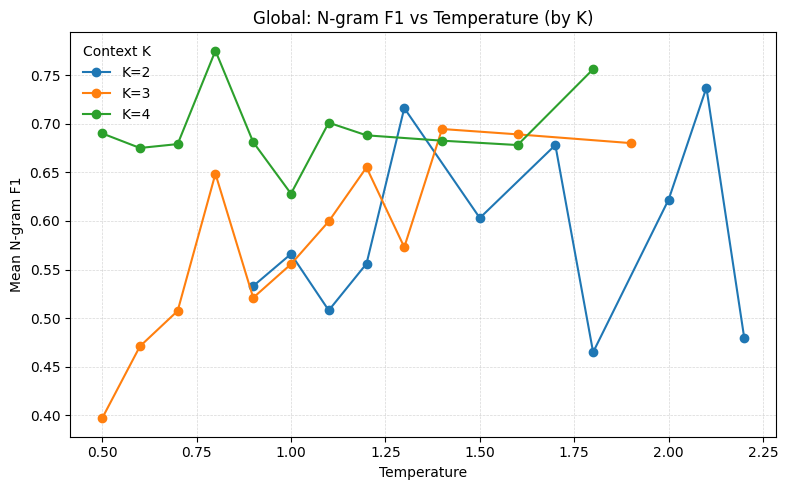

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _make_g_full_from_df(df):
    group_cols = ['k','temperature','use_eos','generator_type','enable_trim','use_context_shifting']
    d = df.copy()
    for c in ['ngram_f1_mean','levenshtein_mean','avg_length','max_length',
              'unique_ratio','hyphen_ratio','underscore_ratio',
              'generation_time_ms','throughput_samples_per_sec','data_size','total_count']:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d[d['total_count'].fillna(0) > 0]
    out = (
        d.groupby(group_cols, dropna=False)
         .agg(
            ngram_f1_mean=('ngram_f1_mean','mean'),
            levenshtein_mean=('levenshtein_mean','mean'),
            avg_length=('avg_length','mean'),
            avg_max_length=('max_length','mean'),
            group_num_runs=('seed','count'),
         )
         .reset_index()
    )
    return out

# Ensure we have g_full
if 'g_full' not in globals():
    if 'df' in globals():
        try:
            _full = pd.to_numeric(df.get('data_size'), errors='coerce').max()
            g_full = _make_g_full_from_df(df[df['data_size'] == _full])
        except Exception:
            g_full = _make_g_full_from_df(df)
    else:
        raise RuntimeError("Neither g_full nor df found. Run earlier cells first.")

# Aggregate: mean F1 by temperature for each K
gf = g_full.copy()
gf = gf.dropna(subset=['k','temperature','ngram_f1_mean'])
summary = (
    gf.groupby(['k','temperature'], as_index=False)['ngram_f1_mean']
      .mean()
      .sort_values(['k','temperature'])
)

fig, ax = plt.subplots(figsize=(8,5))
for k_val, sub in summary.groupby('k'):
    ax.plot(sub['temperature'], sub['ngram_f1_mean'], marker='o', label=f'K={int(k_val)}')

ax.set_xlabel('Temperature')
ax.set_ylabel('Mean N-gram F1')
ax.set_title('Global: N-gram F1 vs Temperature (by K)')
ax.legend(title='Context K', frameon=False)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


#### Visualization 2: Global Levenshtein vs Temperature (by K)

**How to read**
- **X:** temperature. **Y:** mean **Levenshtein** (higher ⇒ more inter-sample diversity).
- **One line per K**; each dot is a **(K, temp)** mean over other knobs.

**What this shows**
- **Diversity does not monotonically increase** with temperature in this snapshot; trends are **flat-to-mild** across K.
- **Moderate temps (~1.0–1.2)** yield **stable diversity**; higher temps don’t consistently push distances up.
- **K=4 vs K=3** differences are **small**; K=2 appears **noisier** (fewer points / less support).
- Caveat: short outputs and frequent **cap-hits** likely **compress** Levenshtein values, masking temperature effects.

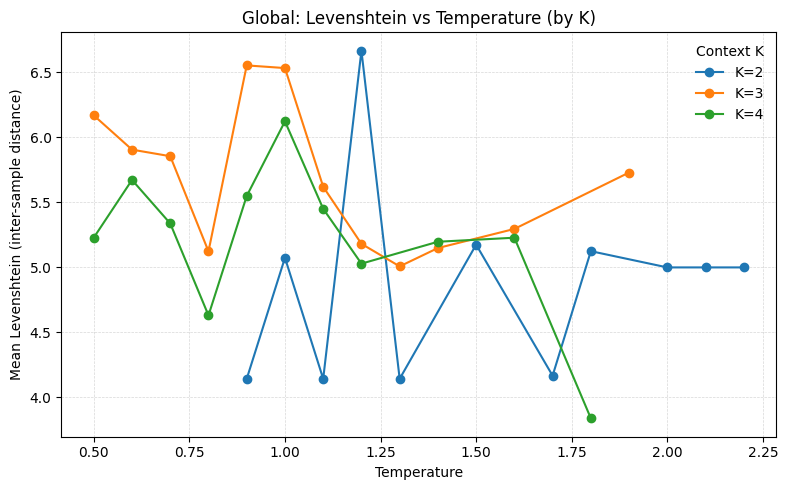

In [18]:
if 'g_full' not in globals():
    raise RuntimeError("g_full not found. Run the earlier aggregation cell first.")

gf = g_full[['k', 'temperature', 'levenshtein_mean']].dropna()
summary = (
    gf.groupby(['k','temperature'], as_index=False)['levenshtein_mean']
      .mean()
      .sort_values(['k','temperature'])
)

fig, ax = plt.subplots(figsize=(8,5))
for k_val, sub in summary.groupby('k'):
    ax.plot(sub['temperature'], sub['levenshtein_mean'], marker='o', label=f'K={int(k_val)}')

ax.set_xlabel('Temperature')
ax.set_ylabel('Mean Levenshtein (inter-sample distance)')
ax.set_title('Global: Levenshtein vs Temperature (by K)')
ax.legend(title='Context K', frameon=False)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

#### Visualization: Length Utilization vs Temperature (by K)

**How to read**
- **X:** temperature. **Y:** mean `avg_length / avg_max_length` (0–1).
- **One line per K**; each dot is the average for that (K, temp) across other knobs.
- Dashed lines mark **0.85** (healthy lower bound), **0.95** (upper bound), **0.98** (cap-hit vicinity).

**What this shows**
- Most points sit **high (≈0.90–0.97)** → outputs are typically **near the cap**.
- **K=3/4** are **stable** around **0.92–0.96** across temps.
- **K=2** is **volatile** (dips ~0.76–0.85 near ~1.7–1.8; spikes to ~1.0 near 2.0–2.1), implying inconsistent stopping and frequent **cap hits** at some temps.
- Overall, utilization is **compressed near the top band**, indicating **limited headroom**; temperature changes alone don’t relieve truncation pressure.



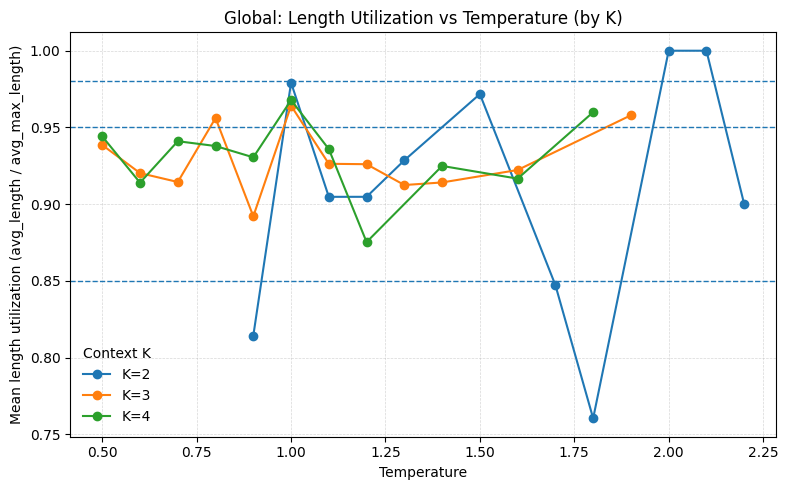

In [19]:
if 'g_full' not in globals():
    raise RuntimeError("g_full not found. Run the aggregation cell first.")

gf = g_full.copy()
gf = gf[['k','temperature','avg_length','avg_max_length']].dropna()
gf['length_ratio'] = (gf['avg_length'] / gf['avg_max_length']).clip(0, 1)

summary = (
    gf.groupby(['k','temperature'], as_index=False)['length_ratio']
      .mean()
      .sort_values(['k','temperature'])
)

fig, ax = plt.subplots(figsize=(8,5))
for k_val, sub in summary.groupby('k'):
    ax.plot(sub['temperature'], sub['length_ratio'], marker='o', label=f'K={int(k_val)}')

# Reference lines for the suggested utilization band
for y in [0.85, 0.95, 0.98]:
    ax.axhline(y=y, linestyle='--', linewidth=1)

ax.set_xlabel('Temperature')
ax.set_ylabel('Mean length utilization (avg_length / avg_max_length)')
ax.set_title('Global: Length Utilization vs Temperature (by K)')
ax.legend(title='Context K', frameon=False)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

### Visualization: Length Utilization vs Temperature — by K, split by EOS/Trim

**How to read**
- One dot per (K, temp); **X:** temperature, **Y:** mean `avg_length / avg_max_length`; one line per **K**.

**What this shows**
- No EOS • No Trim
    - All K’s sit **very high (~0.96–0.98)** → strong **near-cap** behavior.
    - Sparse coverage → **indicative, not conclusive**.
- EOS • No Trim
    - **K=3/4** stay **high (~0.92–0.97)** across temps → still near cap.
    - **K=2** is **volatile** (dips ~0.76–0.85; spikes ~1.0) → inconsistent stopping + frequent **cap
    - EOS alone **doesn’t relieve** truncation pressure.
- EOS • Trim
    - Utilization compresses to a **healthier band (~0.89–0.94)** → **fewer cap hits**.
    - **K=3/4** both stay within the **0.85–0.95** target range.
    - Suggests Trim promotes more **natural stopping** vs. EOS-only.

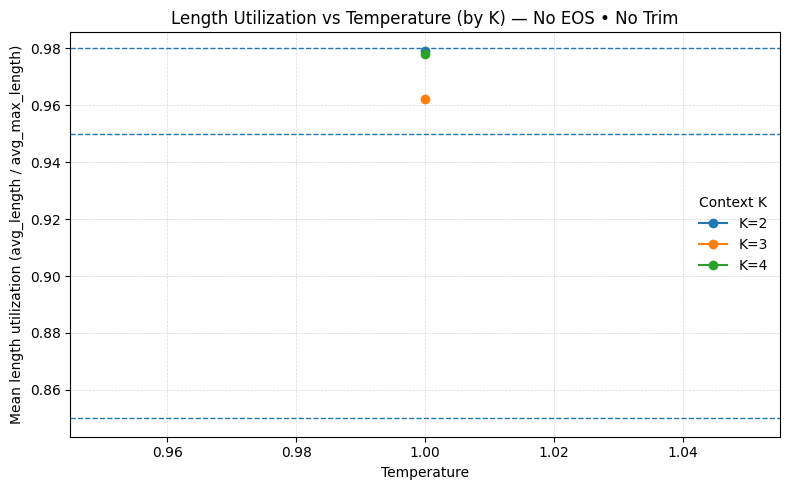

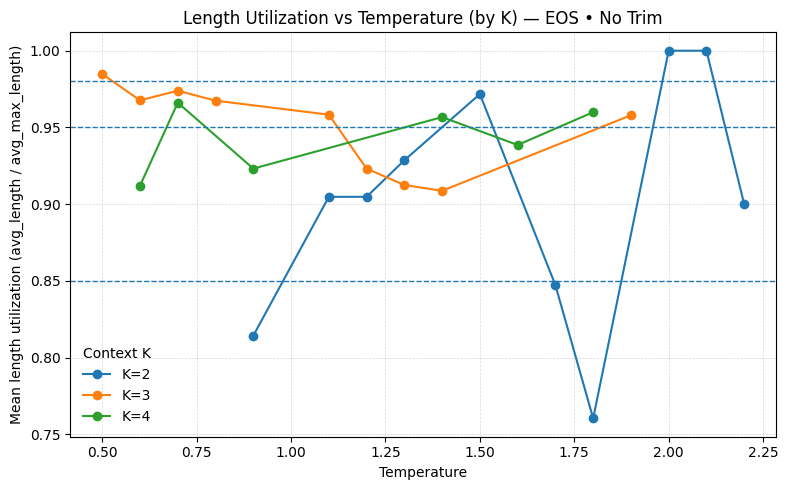

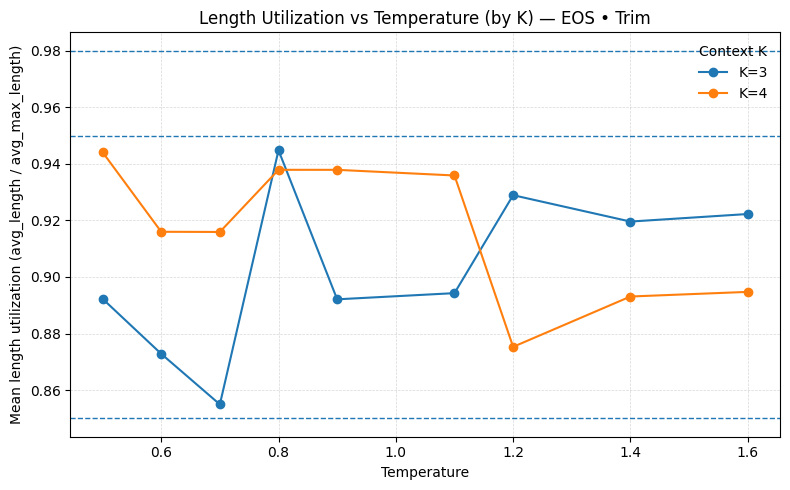

In [20]:
if 'g_full' not in globals():
    raise RuntimeError("g_full not found. Run the aggregation cell first.")

gf = g_full.copy()
need = ['k','temperature','avg_length','avg_max_length','use_eos','enable_trim']
missing = [c for c in need if c not in gf.columns]
if missing:
    raise RuntimeError(f"Missing columns in g_full: {missing}")

# compute length_ratio once
gf = gf.dropna(subset=['avg_length','avg_max_length'])
gf['length_ratio'] = (gf['avg_length'] / gf['avg_max_length']).clip(0, 1)

families = [
    (False, False, "No EOS • No Trim"),
    (True,  False, "EOS • No Trim"),
    (True,  True,  "EOS • Trim"),
]

for eos, trim, title_suffix in families:
    sub = gf[(gf['use_eos'] == eos) & (gf['enable_trim'] == trim)].copy()
    if sub.empty:
        # nothing to plot for this family in the current snapshot
        continue

    # summarize mean length_ratio per (K, temperature)
    summary = (
        sub.groupby(['k','temperature'], as_index=False)['length_ratio']
           .mean()
           .sort_values(['k','temperature'])
    )

    fig, ax = plt.subplots(figsize=(8,5))
    for k_val, gk in summary.groupby('k'):
        ax.plot(gk['temperature'], gk['length_ratio'], marker='o', label=f'K={int(k_val)}')

    # reference lines for utilization bands
    for y in [0.85, 0.95, 0.98]:
        ax.axhline(y=y, linestyle='--', linewidth=1)

    ax.set_xlabel('Temperature')
    ax.set_ylabel('Mean length utilization (avg_length / avg_max_length)')
    ax.set_title(f'Length Utilization vs Temperature (by K) — {title_suffix}')
    ax.legend(title='Context K', frameon=False)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()


### Visualization: Delimiter Usage vs Temperature — Hyphens & Underscores (by K)

**How to read**
- One dot per (K, temp); **X:** temperature.  
- **Y (hyphen chart):** mean `hyphen_ratio` (hyphens / total chars). Bands: **0.04–0.06** ≈ conventional; **<0.03** under-delimited; **>0.07** over-fragmented.  
- **Y (underscore chart):** mean `underscore_ratio`. Quick screens at **0.01** and **0.02**.

**What this shows**
- **Hyphens**
  - **K=3** starts **high (~0.08–0.09)** at low temps (over-fragmented) and trends into the **0.04–0.06** band by ~1.2–1.6.
  - **K=4** declines from **~0.07** toward the target band across ~1.0–1.6.
  - **K=2** often **<0.03** at mid/high temps (under-delimited) with a few near-zero points → inconsistent delimiter use.
- **Underscores**
  - Generally **near zero** across K and temps (good); small bumps **≤~0.01** appear sporadically.
  - A single **outlier (~0.029 at ~2.1, K=2)** suggests occasional token/corpus leakage → worth catching with a validator.


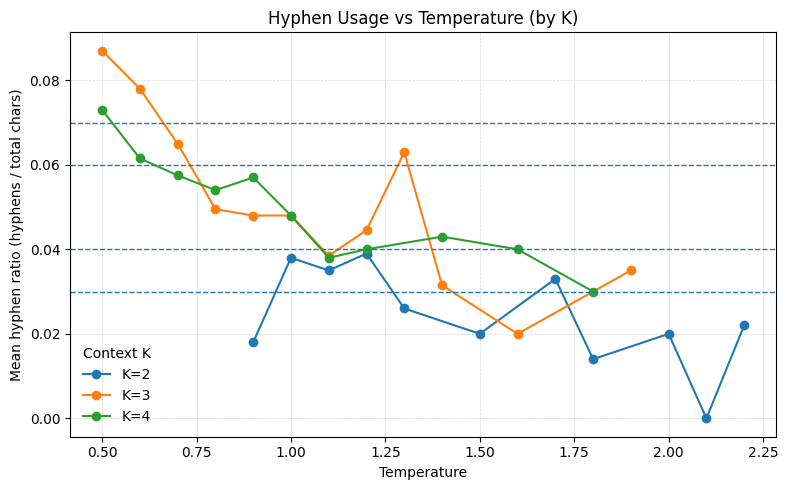

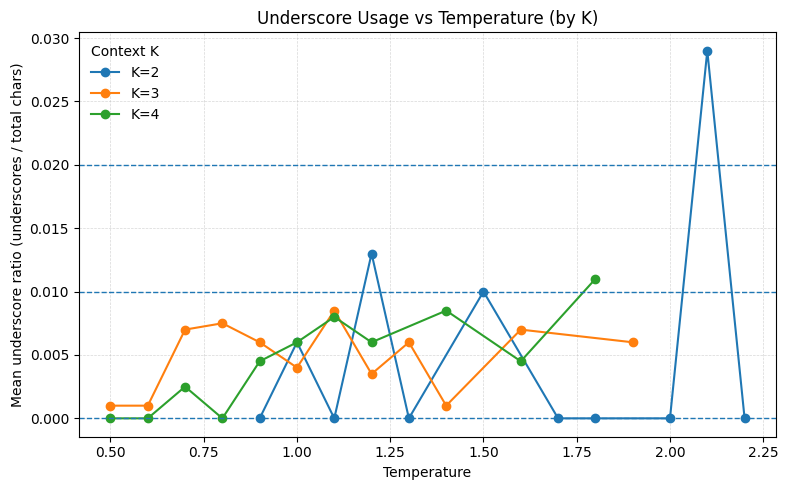

In [21]:
if 'g_full' not in globals():
    raise RuntimeError("g_full not found. Run the aggregation cell first.")

need = ['k','temperature','hyphen_ratio','underscore_ratio']
missing = [c for c in need if c not in g_full.columns]
if missing:
    raise RuntimeError(f"Missing in g_full: {missing}")

gf = g_full[['k','temperature','hyphen_ratio','underscore_ratio']].dropna(subset=['k','temperature'])

# ---- Hyphen ratio ----
hy = (
    gf.dropna(subset=['hyphen_ratio'])
      .groupby(['k','temperature'], as_index=False)['hyphen_ratio']
      .mean()
      .sort_values(['k','temperature'])
)

fig, ax = plt.subplots(figsize=(8,5))
for k_val, sub in hy.groupby('k'):
    ax.plot(sub['temperature'], sub['hyphen_ratio'], marker='o', label=f'K={int(k_val)}')

for y in [0.03, 0.04, 0.06, 0.07]:
    ax.axhline(y=y, linestyle='--', linewidth=1)

ax.set_xlabel('Temperature')
ax.set_ylabel('Mean hyphen ratio (hyphens / total chars)')
ax.set_title('Hyphen Usage vs Temperature (by K)')
ax.legend(title='Context K', frameon=False)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Underscore ratio ----
us = (
    gf.dropna(subset=['underscore_ratio'])
      .groupby(['k','temperature'], as_index=False)['underscore_ratio']
      .mean()
      .sort_values(['k','temperature'])
)

fig, ax = plt.subplots(figsize=(8,5))
for k_val, sub in us.groupby('k'):
    ax.plot(sub['temperature'], sub['underscore_ratio'], marker='o', label=f'K={int(k_val)}')

for y in [0.0, 0.01, 0.02]:
    ax.axhline(y=y, linestyle='--', linewidth=1)

ax.set_xlabel('Temperature')
ax.set_ylabel('Mean underscore ratio (underscores / total chars)')
ax.set_title('Underscore Usage vs Temperature (by K)')
ax.legend(title='Context K', frameon=False)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


### <span style="color:rgb(186, 176, 115); font-size: 24px;"><em>Top-Performer Comparison</em></span>

### Visualization: Top-Quality Configs — Metric Comparison (4-Panel)

**How to read**
- Same 10 configs across all panels:
  1) **Quality Score** (bars, higher = better).
  2) **N-gram F1** (points; shaded band = 0.55–0.70 target).
  3) **Levenshtein** (horizontal points; shaded band = 3–5 target).
  4) **Hyphen Ratio** (points; shaded band = 0.04–0.06 target).

**What this shows**
- **Scores** are tightly clustered (~90–95) → differences are subtle.
- **F1:** Most sit **in/near 0.60–0.70**; a few **>0.70** (possible over-reuse).
- **Levenshtein:** Many configs are **~5.0–5.8** (slightly **above** the 3–5 band), with only a couple near ~4.6–5.0.
- **Hyphen ratio:** Majority fall **inside 0.04–0.06**; one is **low (~0.032)** (under-delimited), a couple hug the **upper edge (~0.06)**.

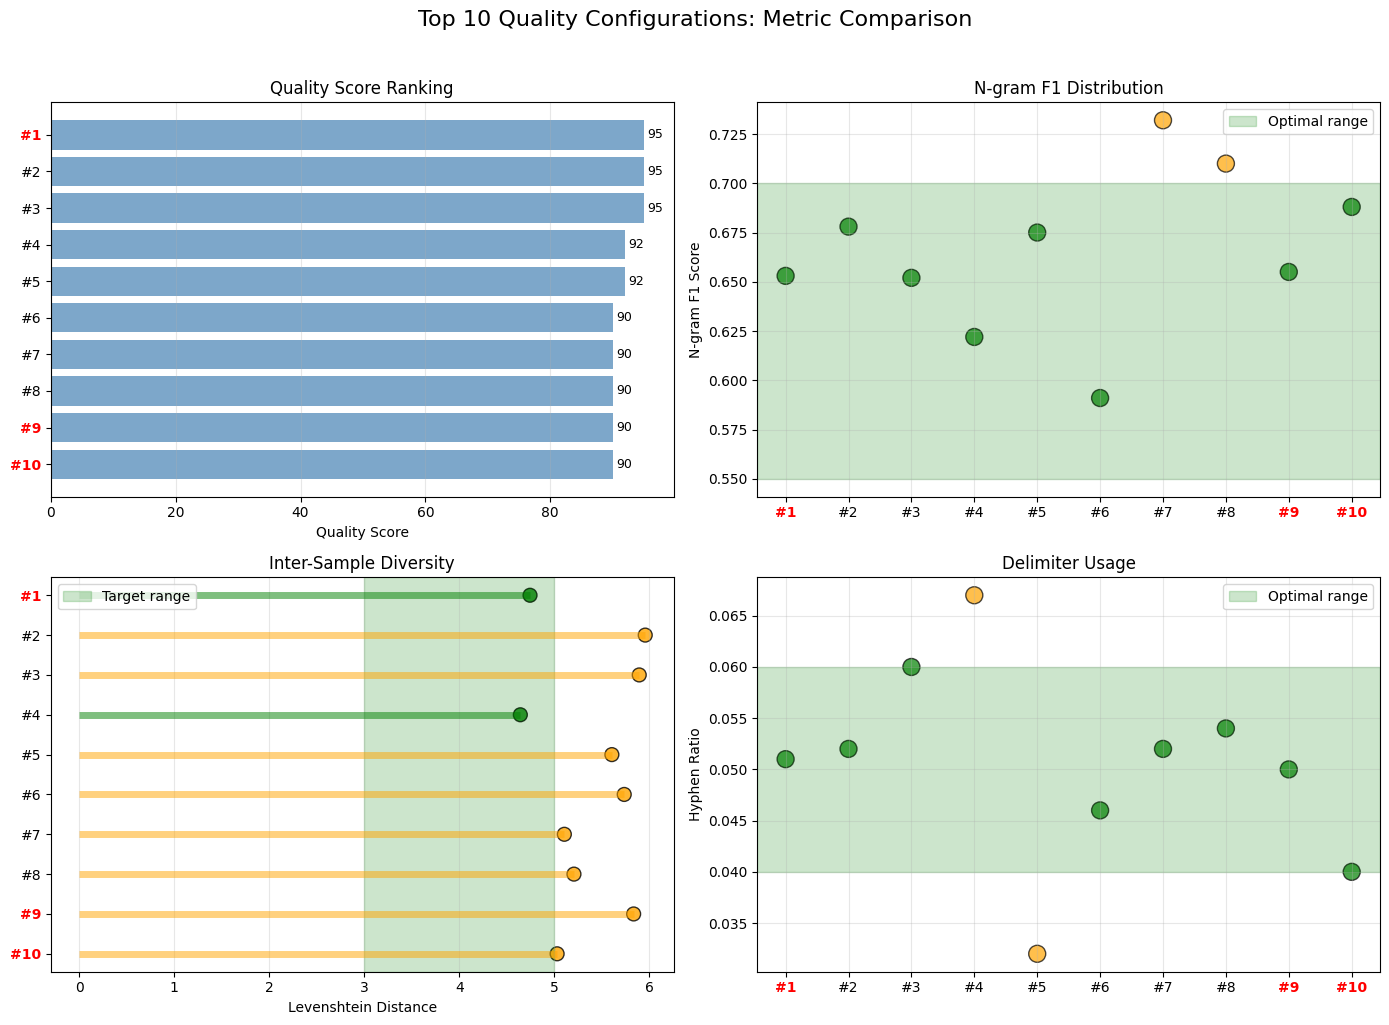

In [22]:
if 'g_full' not in globals() or 'quality_score' not in g_full.columns:
    raise RuntimeError("Run quality scoring cell first")

top_10 = g_full.nlargest(10, 'quality_score').copy()
actual_top_performers = [1, 9, 10]  # Manually validated configs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Top 10 Quality Configurations: Metric Comparison', fontsize=16, y=1.02)

# Helper to color labels red for actual top performers
def apply_red_labels(ax, positions, is_yaxis=True):
    labels = ax.get_yticklabels() if is_yaxis else ax.get_xticklabels()
    for i, label in enumerate(labels):
        if (i+1) in actual_top_performers:
            label.set_color('red')
            label.set_weight('bold')

# Plot 1: Quality Score - Horizontal Bar
ax = axes[0, 0]
y_pos = range(len(top_10))
ax.barh(y_pos, top_10['quality_score'], color='steelblue', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"#{i+1}" for i in y_pos])
apply_red_labels(ax, y_pos, is_yaxis=True)
ax.set_xlabel('Quality Score')
ax.set_title('Quality Score Ranking')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for i, val in enumerate(top_10['quality_score']):
    ax.text(val + 0.5, i, f'{val:.0f}', va='center', fontsize=9)

# Plot 2: N-gram F1 - Scatter
ax = axes[0, 1]
x_pos = range(len(top_10))
colors = ['green' if 0.55 <= v <= 0.70 else 'orange' for v in top_10['ngram_f1_mean']]
ax.scatter(x_pos, top_10['ngram_f1_mean'], s=150, c=colors, alpha=0.7, edgecolors='black')
ax.axhspan(0.55, 0.70, alpha=0.2, color='green', label='Optimal range')
ax.set_xticks(x_pos)
ax.set_xticklabels([f"#{i+1}" for i in x_pos])
apply_red_labels(ax, x_pos, is_yaxis=False)
ax.set_ylabel('N-gram F1 Score')
ax.set_title('N-gram F1 Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Levenshtein - Lollipop
ax = axes[1, 0]
y_pos = range(len(top_10))
colors = ['green' if 3 <= v <= 5 else 'orange' for v in top_10['levenshtein_mean']]
ax.hlines(y_pos, 0, top_10['levenshtein_mean'], colors=colors, alpha=0.5, linewidth=5)
ax.scatter(top_10['levenshtein_mean'], y_pos, s=100, c=colors, alpha=0.8, edgecolors='black')
ax.set_yticks(y_pos)
ax.set_yticklabels([f"#{i+1}" for i in y_pos])
apply_red_labels(ax, y_pos, is_yaxis=True)
ax.set_xlabel('Levenshtein Distance')
ax.set_title('Inter-Sample Diversity')
ax.invert_yaxis()
ax.axvspan(3, 5, alpha=0.2, color='green', label='Target range')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Plot 4: Hyphen Ratio - Dot plot
ax = axes[1, 1]
x_pos = range(len(top_10))
colors = ['green' if 0.04 <= v <= 0.06 else 'orange' for v in top_10['hyphen_ratio']]
ax.scatter(x_pos, top_10['hyphen_ratio'], s=150, c=colors, alpha=0.7, edgecolors='black')
ax.axhspan(0.04, 0.06, alpha=0.2, color='green', label='Optimal range')
ax.set_xticks(x_pos)
ax.set_xticklabels([f"#{i+1}" for i in x_pos])
apply_red_labels(ax, x_pos, is_yaxis=False)
ax.set_ylabel('Hyphen Ratio')
ax.set_title('Delimiter Usage')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Future Scoring Considerations Based on Visualizations

- **Temperature preference:** Shift from a penalty for >1.0 to a **soft preference for 1.0–1.2**, matching the stronger configs.
- **Diversity target:** Relax the band from **3–5 → 4.8–5.6** (or score with a **peak at ~5.2**). Current top configs cluster slightly **above 5**.
- **F1 weighting:** Keep the **0.55–0.70 sweet spot**, but **de-emphasize extreme highs (>0.72)** rather than hard-penalize moderate lows.
- **Hyphen ratio:** Narrow center to **0.045–0.060**; apply only a **mild penalty** below **0.04** (under-delimited). Underscores handled by a **separate validator**, not by score.
- **Cap-hit behavior:** Add a **light penalty when utilization ≥0.98** to discourage truncation-driven wins.
- **Bad-character gate:** Add a **post-gen validator** (/, ., excessive _) as a **pass/fail** or small deduction so quality isn’t inflated by contaminated tokens.

***
# <span style="color: #f91974  ; font-weight: bold; font-size: 32px;">4.</span> <span style="color:rgb(186, 176, 115)  ; font-size: 32px;"><em>Performance - Evaluation</em></span> 

This section examines computational efficiency across all configurations.

**Analysis scope:**
- Generation time measured in milliseconds per batch (seed + samples)
- Rankings identify fastest parameter combinations

In [ ]:
if 'g_full' not in globals():
    raise RuntimeError("g_full not found. Run the aggregation cell first.")

# Filter configurations with valid generation time data
perf = g_full[g_full['gen_time_ms'].notna()].copy()

if perf.empty:
    print("❌ No generation time data available in any configuration")
else:
    # Sort by generation time (ascending = faster is better)
    perf_ranked = perf.sort_values('gen_time_ms', ascending=True).reset_index(drop=True)
    
    print(f"\n{'='*80}")
    print(f" ALL CONFIGURATIONS RANKED BY GENERATION SPEED")
    print(f" Total configurations with timing data: {len(perf_ranked)}")
    print(f"{'='*80}\n")
    
    # Display all ranked configurations (similar format to quality ranking)
    display(perf_ranked[['gen_time_ms', 'k', 'temperature', 'use_eos', 'generator_type', 
                         'enable_trim', 'group_num_runs']])
    
    # Summary statistics
    print(f"\n{'='*80}")
    print(f" GENERATION TIME STATISTICS")
    print(f"{'='*80}\n")
    print(f"  Fastest:  {perf_ranked['gen_time_ms'].min():.2f} ms")
    print(f"  Slowest:  {perf_ranked['gen_time_ms'].max():.2f} ms")
    print(f"  Median:   {perf_ranked['gen_time_ms'].median():.2f} ms")
    print(f"  Mean:     {perf_ranked['gen_time_ms'].mean():.2f} ms")
    print(f"  Std Dev:  {perf_ranked['gen_time_ms'].std():.2f} ms")


 ALL CONFIGURATIONS RANKED BY GENERATION SPEED
 Total configurations with timing data: 48



,gen_time_ms,k,temperature,use_eos,generator_type,enable_trim,group_num_runs
0,7092.000,2,1.1,True,experimental,False,1
1,7111.000,2,2.2,True,experimental,False,1
2,7133.000,2,1.8,True,experimental,False,1
3,7175.000,2,1.2,True,experimental,False,1
4,7184.765,2,1.5,True,experimental,False,2
5,7197.510,2,0.9,True,experimental,False,1
6,7228.500,2,1.7,True,experimental,False,1
7,7246.000,2,2.1,True,experimental,False,1
8,7286.750,2,2.0,True,experimental,False,2
9,7303.500,2,1.3,True,experimental,False,1



 GENERATION TIME STATISTICS

  Fastest:  7092.00 ms
  Slowest:  15908.50 ms
  Median:   10288.74 ms
  Mean:     10916.93 ms
  Std Dev:  2689.70 ms


***
# <span style="color: #f91974  ; font-weight: bold; font-size: 32px;">5.</span> <span style="color:rgb(186, 176, 115)  ; font-size: 32px;"><em>Performance - Visualizations</em></span> 

### Visualization: Top Configurations — Multi-Panel Scorecards

**How to read**
- Four panels compare the same top configs side-by-side:
  1) **Quality Score Ranking** — higher bars = higher composite score.
  2) **Generation Speed** — bar height is **time (ms)**; **lower is faster**.
  3) **N-gram F1 Distribution** — higher = more overlap with corpus; dashed lines show **min/max** among these configs.
  4) **Inter-Sample Diversity (Levenshtein)** — higher = more diversity; dashed lines show **min/max**.

**What this shows**
- **Quality scores** are **tightly clustered (≈90–95)** → the “top-10” are separated by **small margins**.
- **Speed** varies more (≈9.7k–15.6k ms): a few configs are **notably slower** (#2/#3) without clear score gains.
- **F1** ranges ~**0.59–0.73**: a couple above **0.70** (possible **over-reuse**), a couple near **0.60** (more **novel**).
- **Levenshtein** sits mostly **~5.0–5.8**: #2/#3 near **6.0** (more diverse, risk of noise); #4 around **4.6** (tighter/near-duplicate).


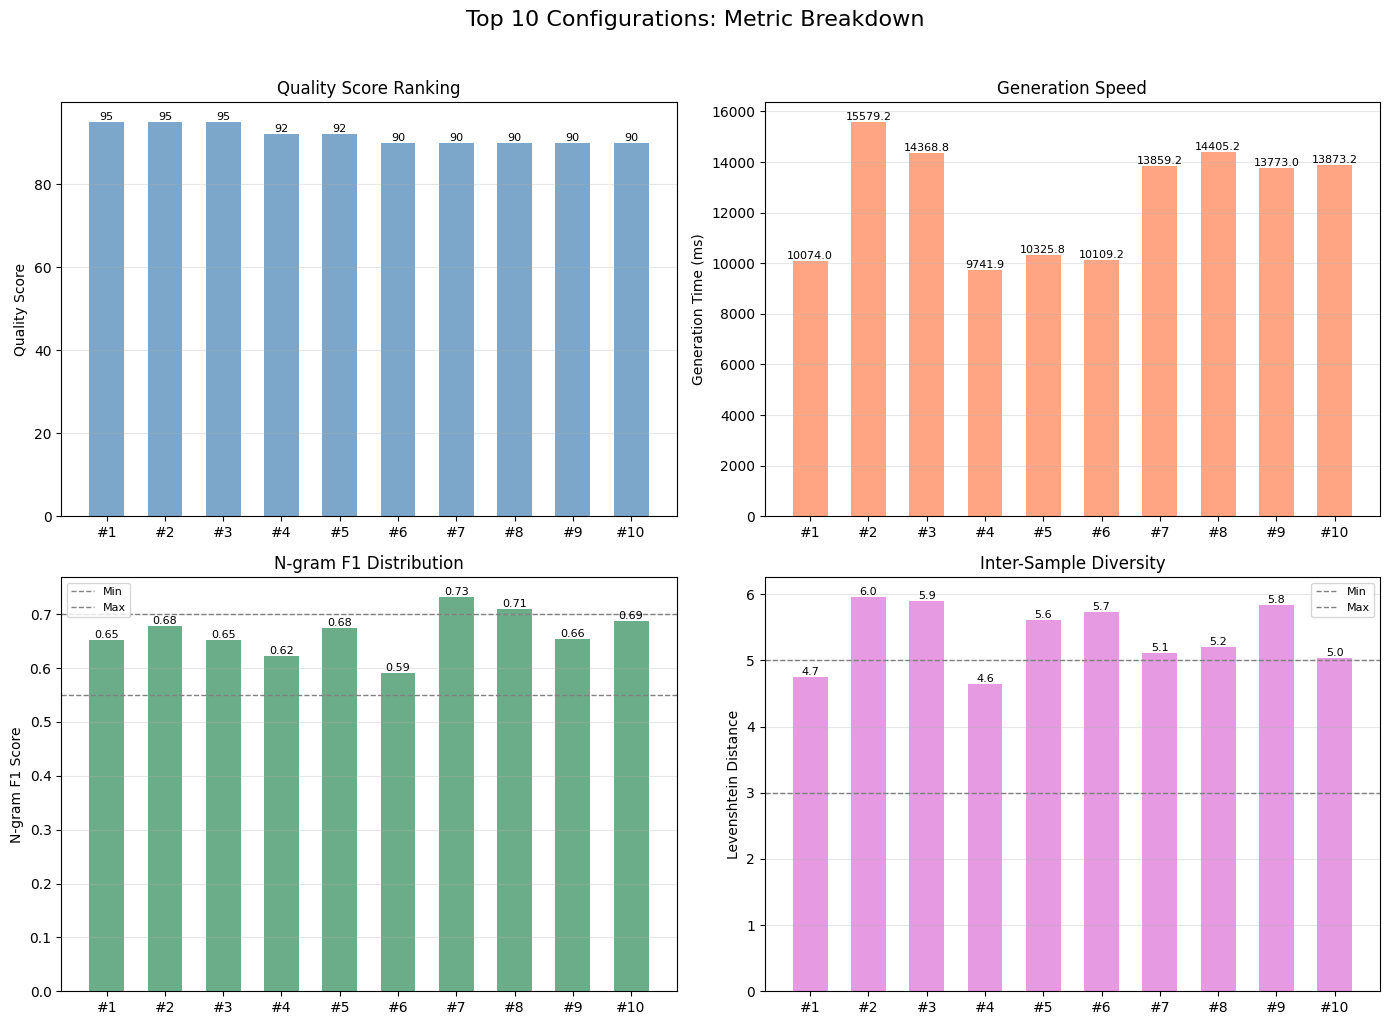

In [24]:
if 'g_full' not in globals() or 'quality_score' not in g_full.columns:
    raise RuntimeError("Run quality scoring cell first")

top_10 = g_full.nlargest(10, 'quality_score').copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Top 10 Configurations: Metric Breakdown', fontsize=16, y=1.02)

x_pos = np.arange(len(top_10))

# Helper function to avoid repetition
def plot_metric(ax, data, ylabel, title, color, format_str='{:.0f}', ref_lines=None):
    bars = ax.bar(x_pos, data, 0.6, color=color, alpha=0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"#{i+1}" for i in range(len(top_10))], rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    if ref_lines:
        for y, label in ref_lines:
            ax.axhline(y=y, color='gray', linestyle='--', linewidth=1, label=label)
        ax.legend(fontsize=8)
    
    for i, (bar, val) in enumerate(zip(bars, data)):
        ax.text(bar.get_x() + bar.get_width()/2., val,
                format_str.format(val), ha='center', va='bottom', fontsize=8)

# Plot 1: Quality Score
plot_metric(axes[0, 0], top_10['quality_score'], 'Quality Score', 
            'Quality Score Ranking', 'steelblue')

# Plot 2: Generation Time
if 'gen_time_ms' in top_10.columns and top_10['gen_time_ms'].notna().any():
    valid = top_10[top_10['gen_time_ms'].notna()]
    plot_metric(axes[0, 1], valid['gen_time_ms'], 'Generation Time (ms)',
                'Generation Speed', 'coral', '{:.1f}')
else:
    axes[0, 1].text(0.5, 0.5, 'No timing data', ha='center', va='center', 
                    transform=axes[0, 1].transAxes)

# Plot 3: N-gram F1
plot_metric(axes[1, 0], top_10['ngram_f1_mean'], 'N-gram F1 Score',
            'N-gram F1 Distribution', 'seagreen', '{:.2f}',
            ref_lines=[(0.55, 'Min'), (0.70, 'Max')])

# Plot 4: Levenshtein
plot_metric(axes[1, 1], top_10['levenshtein_mean'], 'Levenshtein Distance',
            'Inter-Sample Diversity', 'orchid', '{:.1f}',
            ref_lines=[(3, 'Min'), (5, 'Max')])

plt.tight_layout()
plt.show()

### Visualization: 15 Slowest Configurations

**How to read**
- Horizontal bars sorted by **generation time (ms)** — **longer = slower**.
- Labels show **rank, K, temperature (T), generator type** (exp/base).
- Bars ordered with **slowest at bottom** (reversed for plotting clarity).

**What this shows**
- **Slowest** configurations: **~15.6–15.9k ms** (notably **T=0.6–0.7, exp**).
- **Fastest among the slow**: **~13.6–14.0k ms** (e.g., **K=4, T≈1.1–1.4, exp/base**).
- Spread is **~2.3s (~17%)** → speed differences exist but are modest.
- Both **base** and **experimental** appear among the slowest; as expected **K=4** dominates.

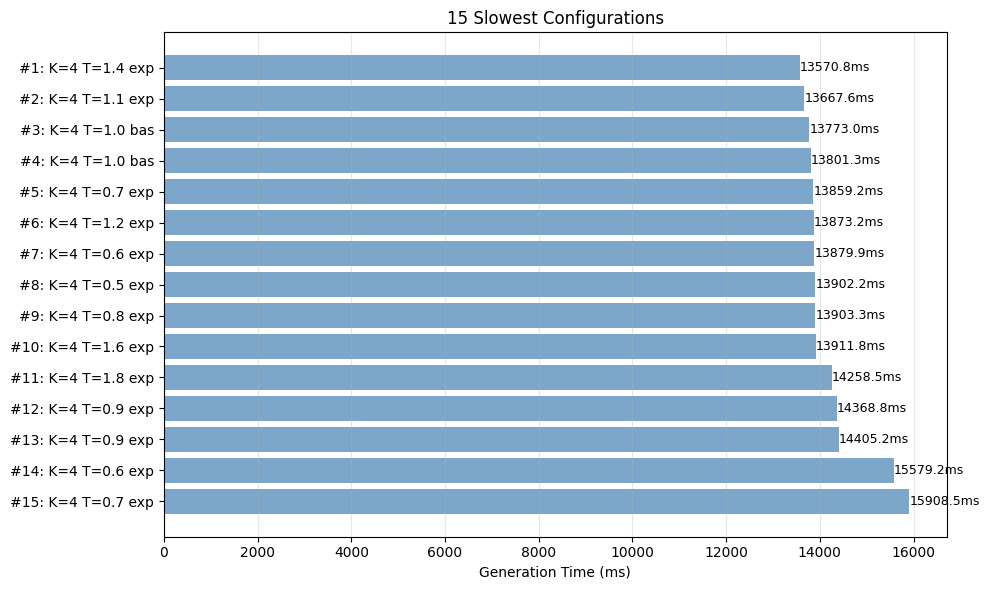

In [30]:
if 'g_full' not in globals():
    raise RuntimeError("g_full not found. Run the aggregation cell first.")

perf = g_full[g_full['gen_time_ms'].notna()].copy()

if perf.empty:
    print("❌ No generation time data available")
else:
    top_15 = perf.nlargest(15, 'gen_time_ms', keep='first').iloc[::-1]  # Sort ascending, reverse for plotting
    top_15['label'] = top_15.apply(
        lambda r: f"K={int(r['k'])} T={r['temperature']:.1f} {r['generator_type'][:3]}", axis=1
    )
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(top_15)), top_15['gen_time_ms'], color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels([f"#{i+1}: {label}" for i, label in enumerate(top_15['label'])])
    ax.set_xlabel('Generation Time (ms)')
    ax.set_title('15 Slowest Configurations')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    for i, time in enumerate(top_15['gen_time_ms']):
        ax.text(time + 0.5, i, f'{time:.1f}ms', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()